In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [2]:
from cartpole import CartPole, remap_angle

STATE_NAMES = [
    "x",
    "x_dot",
    "theta",
    "theta_dot",
]

STATE_LABELS = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]

system = CartPole(visual=False)

print("Default state:", system.getState())
print("delta_time:", system.delta_time)

Default state: [0.         0.         3.14159265 0.        ]
delta_time: 0.1


In [3]:
def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path


def one_step_zero_force(initial_state):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()
    delta_x = x_next - x0

    return x0, x_next, delta_x


def make_linear_features(states, use_intercept=True):
    states = np.asarray(states)

    if states.ndim == 1:
        states = states[None, :]

    if use_intercept:
        ones = np.ones(states.shape[0])
        Phi = np.column_stack([states, ones])
    else:
        Phi = states.copy()

    return Phi


def remap_angle_array(theta_values):
    return np.array([remap_angle(theta) for theta in theta_values])


def remap_trajectory_angle(trajectory):
    trajectory_plot = trajectory.copy()
    trajectory_plot[:, 2] = remap_angle_array(trajectory_plot[:, 2])
    return trajectory_plot

In [4]:
dataset_path = DATA_DIR / "task1_3_linear_model_dataset_500.npz"

data = np.load(dataset_path)

X_initial = data["X_initial"]
Delta_X = data["Delta_X"]

print("Loaded dataset:", dataset_path)
print("X_initial shape:", X_initial.shape)
print("Delta_X shape:", Delta_X.shape)

Loaded dataset: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_3_linear_model_dataset_500.npz
X_initial shape: (500, 4)
Delta_X shape: (500, 4)


In [5]:
Phi = make_linear_features(X_initial, use_intercept=True)

W_hat, residuals, rank, singular_values = np.linalg.lstsq(
    Phi,
    Delta_X,
    rcond=None
)

print("Phi shape:", Phi.shape)
print("W_hat shape:", W_hat.shape)
print("rank:", rank)
W_hat

Phi shape: (500, 5)
W_hat shape: (5, 4)
rank: 5


array([[-3.08317198e-05,  1.48492463e-03,  5.26162958e-04,
         1.25787443e-02],
       [ 9.97764615e-02, -1.24939619e-03, -3.48285573e-04,
        -2.23318593e-03],
       [ 1.48919934e-02,  2.42973086e-01,  5.68483571e-02,
         9.93263299e-01],
       [ 1.02858493e-03,  2.38855109e-02,  1.00961190e-01,
         1.65461681e-02],
       [ 1.79607360e-03,  3.63950514e-02,  6.99189192e-04,
         1.09226171e-02]])

In [6]:
def rollout_true_zero_force(initial_state, num_steps):
    """
    True CartPole rollout using performAction(0.0).
    """
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = system.getState()

    for step in range(num_steps):
        system.performAction(0.0)
        trajectory[step + 1] = system.getState()

    return trajectory


def predict_delta_linear(state, W_hat):
    """
    Predict Delta X using the fitted linear model.
    """
    phi = make_linear_features(state, use_intercept=True)
    delta_pred = (phi @ W_hat)[0]
    return delta_pred


def rollout_linear_model(initial_state, num_steps, W_hat, remap_theta=True):
    """
    Iterated model rollout:
        X_{n+1} = X_n + f(X_n)

    If remap_theta=True, remap theta after each model step.
    """
    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = np.asarray(initial_state, dtype=float)

    if remap_theta:
        trajectory[0, 2] = remap_angle(trajectory[0, 2])

    for step in range(num_steps):
        current_state = trajectory[step]
        delta_pred = predict_delta_linear(current_state, W_hat)
        next_state = current_state + delta_pred

        if remap_theta:
            next_state[2] = remap_angle(next_state[2])

        trajectory[step + 1] = next_state

    return trajectory

In [7]:
initial_state = np.array([0.0, 0.0, np.pi, 12.0])
num_steps = 80

true_trajectory = rollout_true_zero_force(initial_state, num_steps)

model_trajectory_remap = rollout_linear_model(
    initial_state,
    num_steps,
    W_hat,
    remap_theta=True,
)

model_trajectory_no_remap = rollout_linear_model(
    initial_state,
    num_steps,
    W_hat,
    remap_theta=False,
)

print("true_trajectory shape:", true_trajectory.shape)
print("model_trajectory_remap shape:", model_trajectory_remap.shape)
print("model_trajectory_no_remap shape:", model_trajectory_no_remap.shape)

print("\nFinal true state:")
print(true_trajectory[-1])

print("\nFinal model state, remap:")
print(model_trajectory_remap[-1])

print("\nFinal model state, no remap:")
print(model_trajectory_no_remap[-1])

true_trajectory shape: (81, 4)
model_trajectory_remap shape: (81, 4)
model_trajectory_no_remap shape: (81, 4)

Final true state:
[-12.08069251  -1.57947448   1.74244269  -4.5075364 ]

Final model state, remap:
[317.84416572 117.70601075  -0.94937777 163.39759053]

Final model state, no remap:
[3.66773715e+10 1.08202149e+11 1.22566859e+11 3.61185017e+11]


In [8]:
def plot_rollout_comparison(
    true_trajectory,
    model_trajectory,
    name,
    filename,
    first_n_steps=None,
    remap_true_theta_for_plot=True,
):
    """
    Plot true vs model trajectories for all 4 state variables.
    """
    if remap_true_theta_for_plot:
        true_plot = remap_trajectory_angle(true_trajectory)
    else:
        true_plot = true_trajectory.copy()

    model_plot = model_trajectory.copy()

    if first_n_steps is not None:
        true_plot = true_plot[:first_n_steps + 1]
        model_plot = model_plot[:first_n_steps + 1]
        time = np.arange(first_n_steps + 1)
    else:
        time = np.arange(true_plot.shape[0])

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    for dim in range(4):
        ax = axes[dim]

        ax.plot(time, true_plot[:, dim], label="True")
        ax.plot(time, model_plot[:, dim], linestyle="--", label="Linear model")

        ax.set_xlabel("Time step")
        ax.set_ylabel(STATE_LABELS[dim])
        ax.set_title(STATE_NAMES[dim])
        ax.grid(True)
        ax.legend()

    fig.suptitle(name)
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_linear_rollout_local_view.png


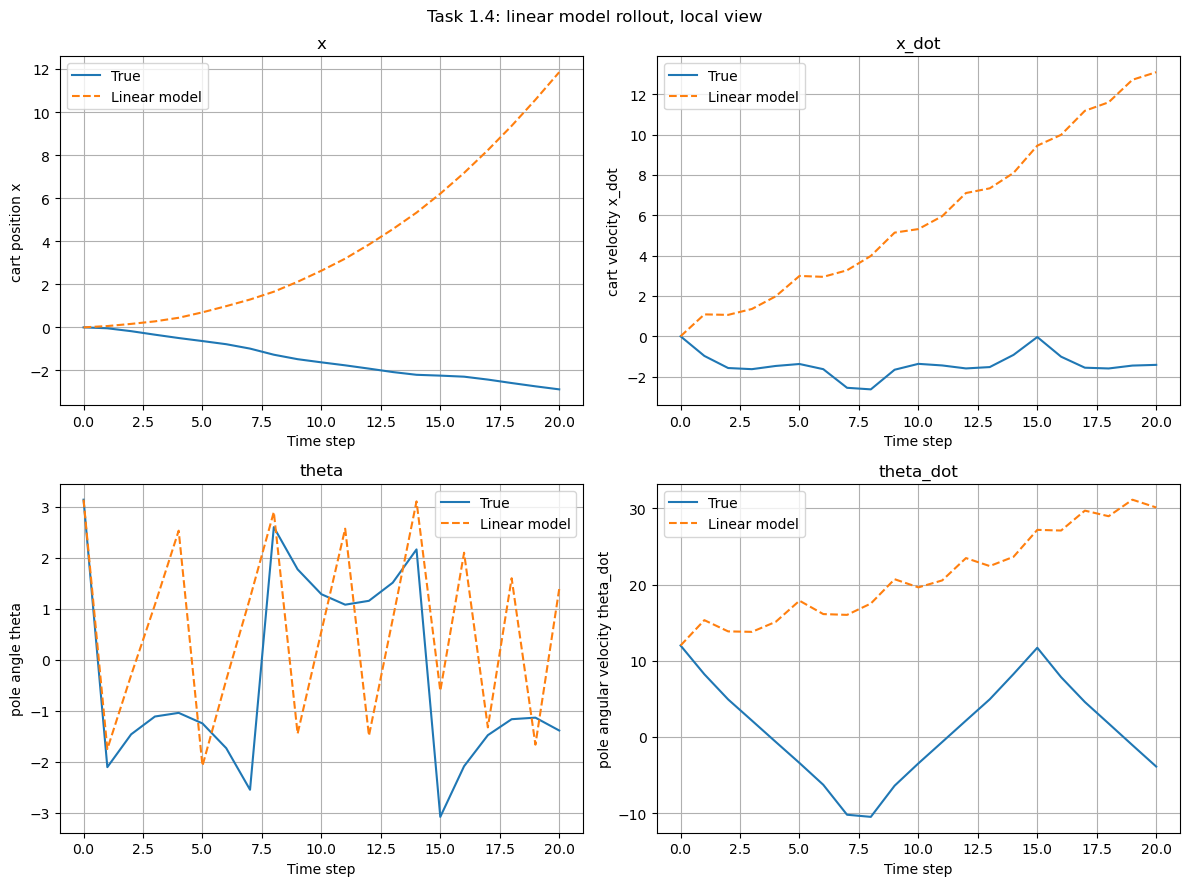

In [34]:
plot_rollout_comparison(
    true_trajectory=true_trajectory,
    model_trajectory=model_trajectory_remap,
    name="Task 1.4: linear model rollout, local view",
    filename="sf3_task1_4_linear_rollout_local_view.png",
    first_n_steps=20,
    remap_true_theta_for_plot=True,
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_linear_rollout_longer_horizon.png


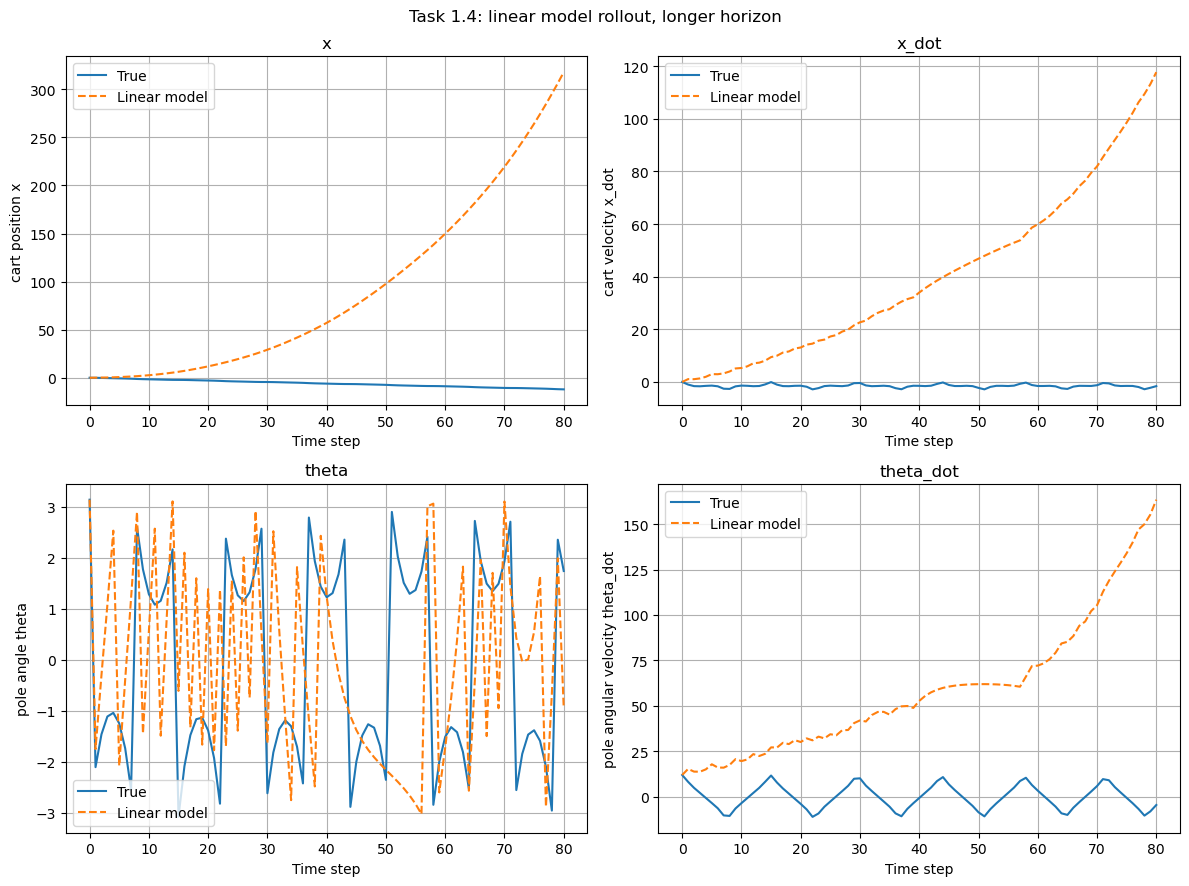

In [10]:
plot_rollout_comparison(
    true_trajectory=true_trajectory,
    model_trajectory=model_trajectory_remap,
    name="Task 1.4: linear model rollout, longer horizon",
    filename="sf3_task1_4_linear_rollout_longer_horizon.png",
    first_n_steps=None,
    remap_true_theta_for_plot=True,
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_remap_vs_no_remap.png


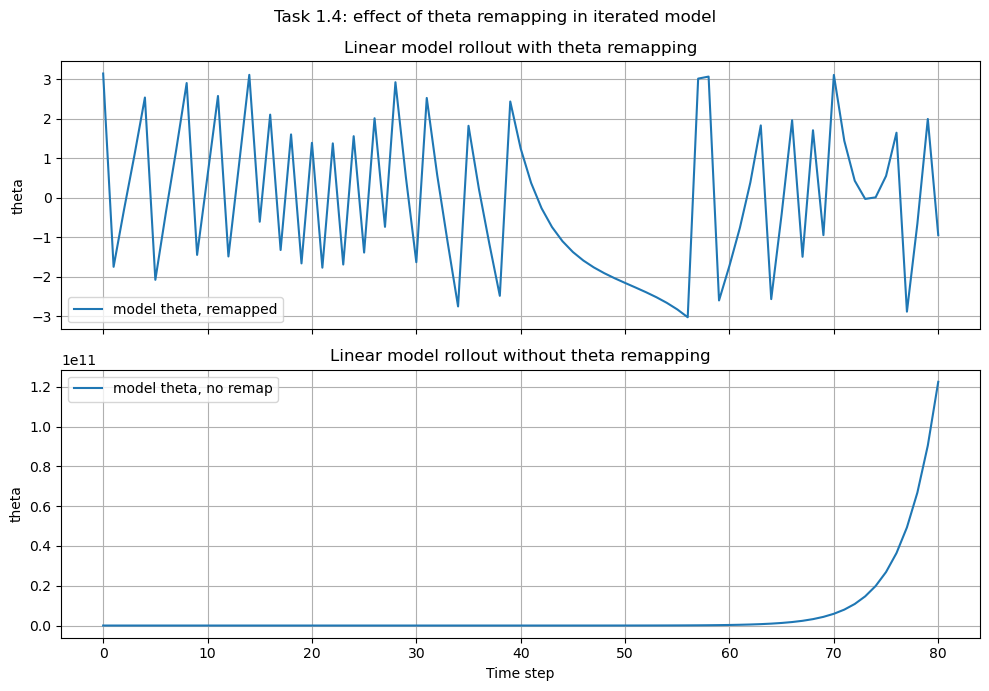

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

time = np.arange(num_steps + 1)

axes[0].plot(time, model_trajectory_remap[:, 2], label="model theta, remapped")
axes[0].set_ylabel("theta")
axes[0].set_title("Linear model rollout with theta remapping")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(time, model_trajectory_no_remap[:, 2], label="model theta, no remap")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("theta")
axes[1].set_title("Linear model rollout without theta remapping")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Task 1.4: effect of theta remapping in iterated model")
fig.tight_layout()

save_figure(fig, "sf3_task1_4_remap_vs_no_remap.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_rollout_error_accumulation.png


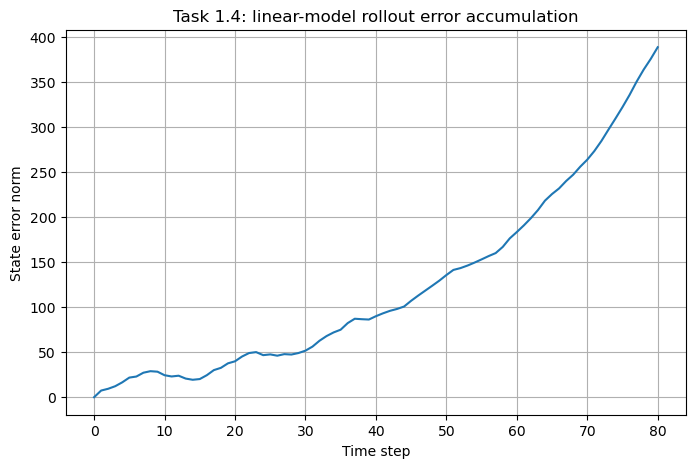

Initial error norm: 0.0
Error norm after 5 steps: 21.812095201903603
Error norm after 10 steps: 24.448104543860712
Error norm after 20 steps: 39.91544579816321
Final error norm: 388.9457759201742


In [12]:
true_plot = remap_trajectory_angle(true_trajectory)
model_plot = model_trajectory_remap.copy()

rollout_errors = model_plot - true_plot

rollout_mse_over_time = np.mean(rollout_errors ** 2, axis=1)
rollout_error_norm = np.linalg.norm(rollout_errors, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(num_steps + 1), rollout_error_norm)

ax.set_xlabel("Time step")
ax.set_ylabel("State error norm")
ax.set_title("Task 1.4: linear-model rollout error accumulation")
ax.grid(True)

save_figure(fig, "sf3_task1_4_rollout_error_accumulation.png")
plt.show()

print("Initial error norm:", rollout_error_norm[0])
print("Error norm after 5 steps:", rollout_error_norm[5])
print("Error norm after 10 steps:", rollout_error_norm[10])
print("Error norm after 20 steps:", rollout_error_norm[20])
print("Final error norm:", rollout_error_norm[-1])

In [13]:
initial_conditions = {
    "near_downward_small": np.array([0.0, 0.0, np.pi, 2.0]),
    "near_downward_large": np.array([0.0, 0.0, np.pi, 8.0]),
    "full_rotation": np.array([0.0, 0.0, np.pi, 12.0]),
    "near_upright": np.array([0.0, 0.0, 0.2, 0.0]),
}

num_steps_multi = 80

rollout_summary = {}

for name, initial_state in initial_conditions.items():
    true_traj = rollout_true_zero_force(initial_state, num_steps_multi)
    model_traj = rollout_linear_model(
        initial_state,
        num_steps_multi,
        W_hat,
        remap_theta=True,
    )

    true_plot = remap_trajectory_angle(true_traj)
    model_plot = model_traj.copy()

    error_norm = np.linalg.norm(model_plot - true_plot, axis=1)

    rollout_summary[name] = {
        "true": true_traj,
        "model": model_traj,
        "error_norm": error_norm,
    }

    print(name)
    print("  final error norm:", error_norm[-1])
    print("  error after 10 steps:", error_norm[10])
    print("  error after 20 steps:", error_norm[20])
    print()

near_downward_small
  final error norm: 101.20249406628096
  error after 10 steps: 5.13722908681035
  error after 20 steps: 7.543780618028454

near_downward_large
  final error norm: 164.79166823577694
  error after 10 steps: 6.919321300731589
  error after 20 steps: 14.276324890650866

full_rotation
  final error norm: 388.9457759201742
  error after 10 steps: 24.448104543860712
  error after 20 steps: 39.91544579816321

near_upright
  final error norm: 188.1440676278808
  error after 10 steps: 6.407413676218597
  error after 20 steps: 14.8471864465564



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_error_multiple_initial_conditions.png


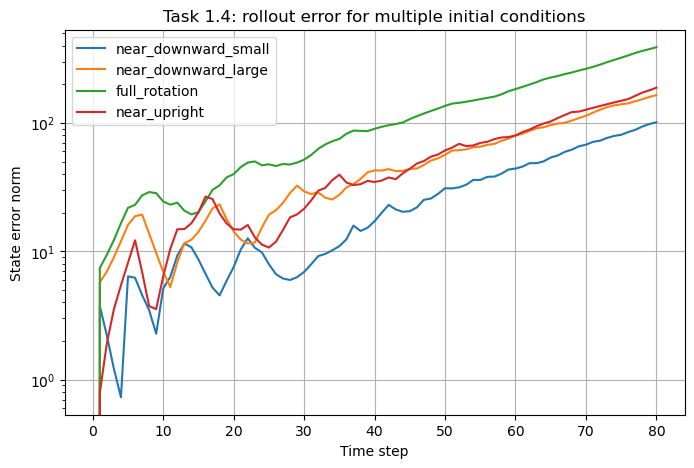

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

time = np.arange(num_steps_multi + 1)

for name, result in rollout_summary.items():
    ax.plot(time, result["error_norm"], label=name)

ax.set_xlabel("Time step")
ax.set_ylabel("State error norm")
ax.set_title("Task 1.4: rollout error for multiple initial conditions")
ax.set_yscale("log")
ax.grid(True)
ax.legend()

save_figure(fig, "sf3_task1_4_error_multiple_initial_conditions.png")
plt.show()

In [15]:
def plot_phase_comparison(true_trajectory, model_trajectory, name, filename):
    true_plot = remap_trajectory_angle(true_trajectory)
    model_plot = model_trajectory.copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(true_plot[:, 0], true_plot[:, 1], label="True")
    axes[0].plot(model_plot[:, 0], model_plot[:, 1], linestyle="--", label="Linear model")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("x_dot")
    axes[0].set_title("Cart phase portrait")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(true_plot[:, 2], true_plot[:, 3], label="True")
    axes[1].plot(model_plot[:, 2], model_plot[:, 3], linestyle="--", label="Linear model")
    axes[1].set_xlabel("theta, remapped")
    axes[1].set_ylabel("theta_dot")
    axes[1].set_title("Pole phase portrait")
    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(name)
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_4_phase_portrait_comparison.png


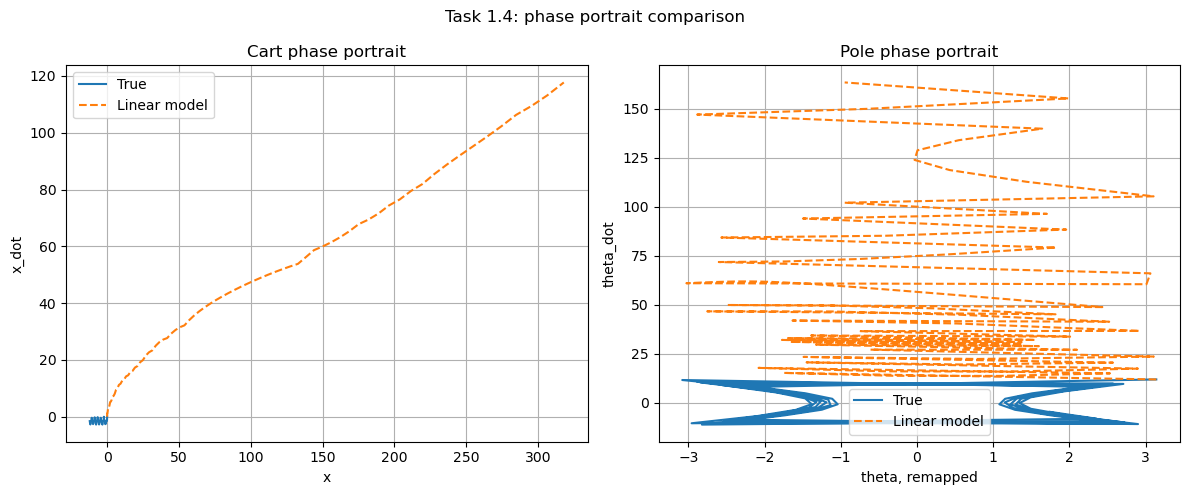

In [16]:
plot_phase_comparison(
    true_trajectory=true_trajectory,
    model_trajectory=model_trajectory_remap,
    name="Task 1.4: phase portrait comparison",
    filename="sf3_task1_4_phase_portrait_comparison.png",
)